# Phase 3 - EDA & Feature Engineering
**Dataset:** Bank Customer Churn Modelling   
**Goal:** Explore churn patterns across demographics, balance and activity metrics   
**Input:** `data/churn.db` - `churn_clean`    
**Output:** `data/churn_clean_export.csv`


## Setup

In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

## Loadin the clean data

In [3]:
#load the data
conn = sqlite3.connect('../data/churn.db')
df = pd.read_sql("SELECT * FROM churn_clean", conn)
conn.close()

print(f"Shape: {df.shape}")
df.head(3)

Shape: (10000, 16)


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_band,balance_segment,credit_band,value_tier
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40 - 49,Zero Balance,Fair,Mid Value
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40 - 49,Mid (50k - 100k),Fair,Mid Value
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40 - 49,Very High (150k+),Poor,High Value


## Univariate analysis
### Chart1 - Overall churn split

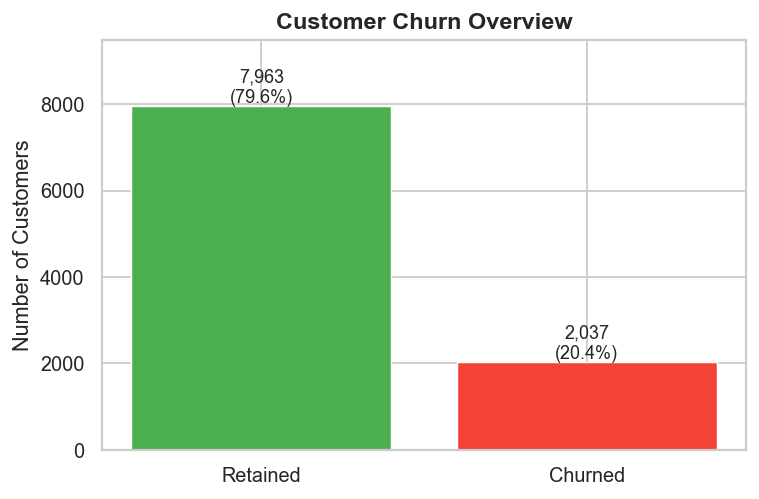

In [4]:
churn_counts  = df['Exited'].value_counts()
churn_labels  = ['Retained', 'Churned']
churn_colors  = ['#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_labels, churn_counts.values,
              color=churn_colors, edgecolor='white', linewidth=0.8)

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{bar.get_height():,}\n({pct:.1f}%)',
            ha='center', fontsize=10)

ax.set_title('Customer Churn Overview')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, 9500)
plt.tight_layout()
plt.savefig('../notebooks/chart1_churn_overview.png', bbox_inches='tight')
plt.show()

### Chart2 - Age distribution by churn status

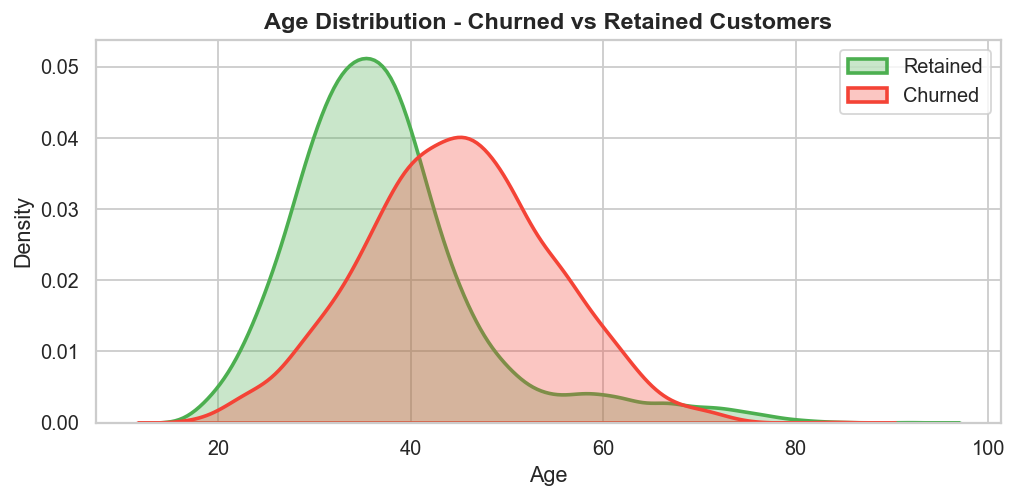

In [5]:
fig, ax = plt.subplots(figsize = (8, 4))

sns.kdeplot(data=df[df['Exited']==0]['Age'], ax=ax, linewidth=2, label = 'Retained', fill=True, alpha=0.3, color='#4CAF50')
sns.kdeplot(data=df[df['Exited']==1]['Age'], ax=ax, linewidth=2, label = 'Churned', fill=True, alpha=0.3, color='#F44336')

ax.set_title('Age Distribution - Churned vs Retained Customers')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart2_age_distribution.png', bbox_inches='tight')
plt.show()

### Chart3 - Balance distribution by churn status

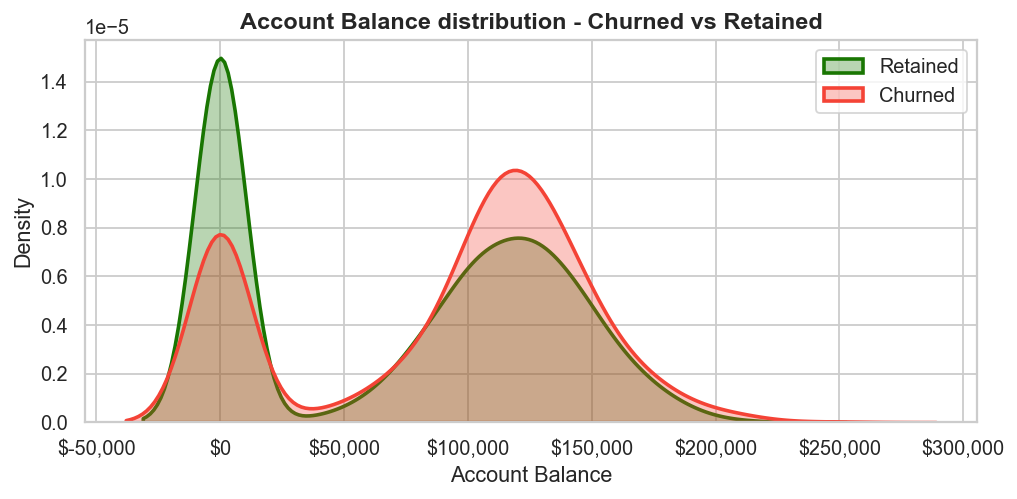

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(data=df[df['Exited']==0]['Balance'], ax=ax, linewidth=2, label='Retained', fill=True, alpha=0.3, color='#197602')
sns.kdeplot(data=df[df['Exited']==1]['Balance'], ax=ax, linewidth=2, label='Churned', fill=True, alpha=0.3, color='#F44336')
ax.set_title('Account Balance distribution - Churned vs Retained')
ax.set_xlabel('Account Balance')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart3_balance_distribution.png', bbox_inches='tight')

## Bivariate analysis
### Chart4 - Churn rate by geography

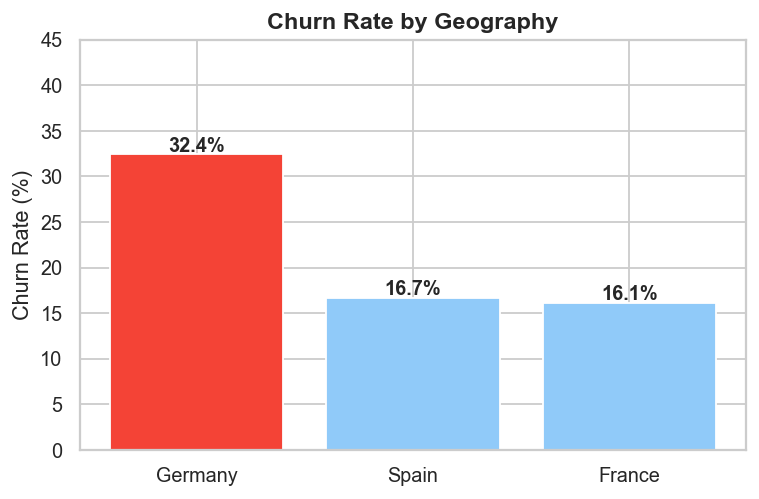

In [7]:
geo_churn = (df.groupby('Geography')['Exited']
               .mean()
               .mul(100)
               .round(2)
               .sort_values(ascending=False))

colors = ['#F44336' if v == geo_churn.max() else '#90CAF9' for v in geo_churn.values]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(geo_churn.index, geo_churn.values,
              color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Geography')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 45)
plt.tight_layout()
plt.savefig('../notebooks/chart4_churn_by_geography.png', bbox_inches='tight')
plt.show()

### Chart5 - Churn rate by age band

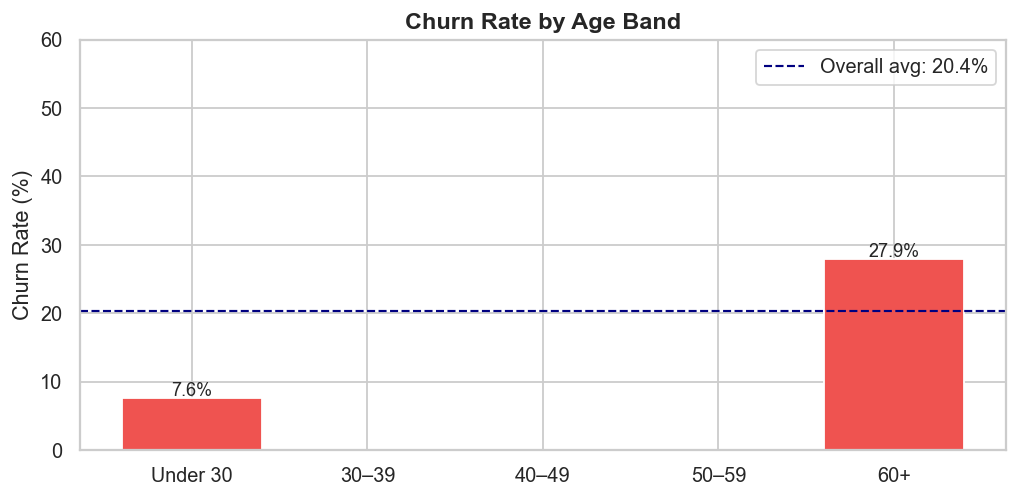

In [8]:
age_order  = ['Under 30', '30–39', '40–49', '50–59', '60+']

age_churn  = (df.groupby('age_band')['Exited']
                .mean()
                .reindex(age_order)
                .mul(100)
                .round(2))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(age_churn.index, age_churn.values,
              color='#EF5350', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=10)

ax.axhline(df['Exited'].mean() * 100, color='navy',
           linestyle='--', linewidth=1.2, label=f"Overall avg: {df['Exited'].mean()*100:.1f}%")
ax.set_title('Churn Rate by Age Band')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart5_churn_by_age.png', bbox_inches='tight')
plt.show()

### Chart6 - Churn rate by number of products

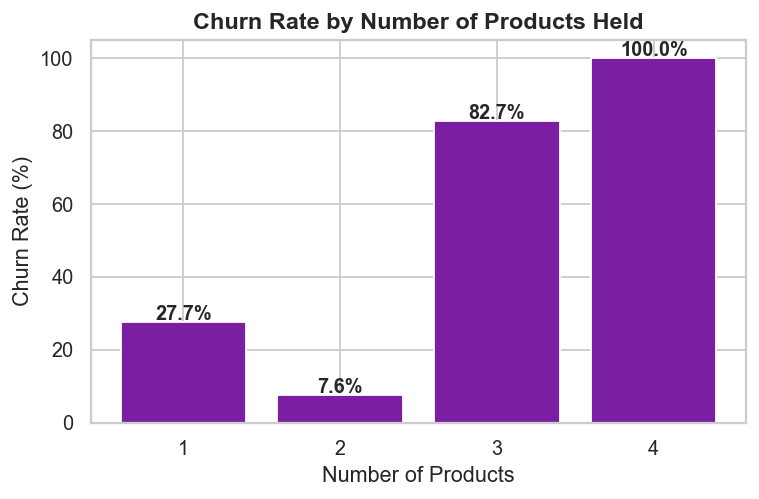

In [9]:
prod_churn = (df.groupby('NumOfProducts')['Exited']
                .mean()
                .mul(100)
                .round(2))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(prod_churn.index.astype(str), prod_churn.values,
              color='#7B1FA2', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Number of Products Held')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../notebooks/chart6_churn_by_products.png', bbox_inches='tight')
plt.show()

### Chart7 - Churn rate by active membership & gender

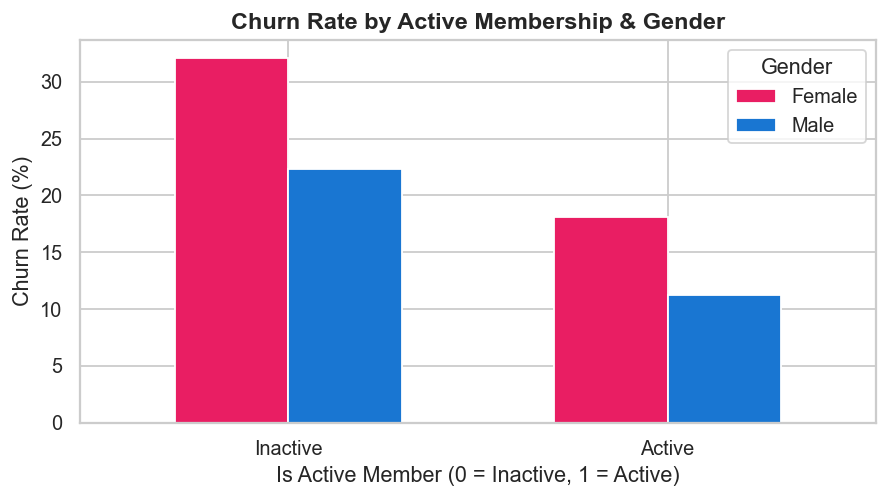

In [10]:
active_gender = (df.groupby(['IsActiveMember', 'Gender'])['Exited']
                   .mean()
                   .mul(100)
                   .round(2)
                   .unstack())

fig, ax = plt.subplots(figsize=(7, 4))
active_gender.plot(kind='bar', ax=ax, color=['#E91E63', '#1976D2'],
                   edgecolor='white', width=0.6)

ax.set_title('Churn Rate by Active Membership & Gender')
ax.set_xlabel('Is Active Member (0 = Inactive, 1 = Active)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(['Inactive', 'Active'], rotation=0)
ax.legend(title='Gender')
plt.tight_layout()
plt.savefig('../notebooks/chart7_churn_active_gender.png', bbox_inches='tight')
plt.show()

## Correlation heatmap

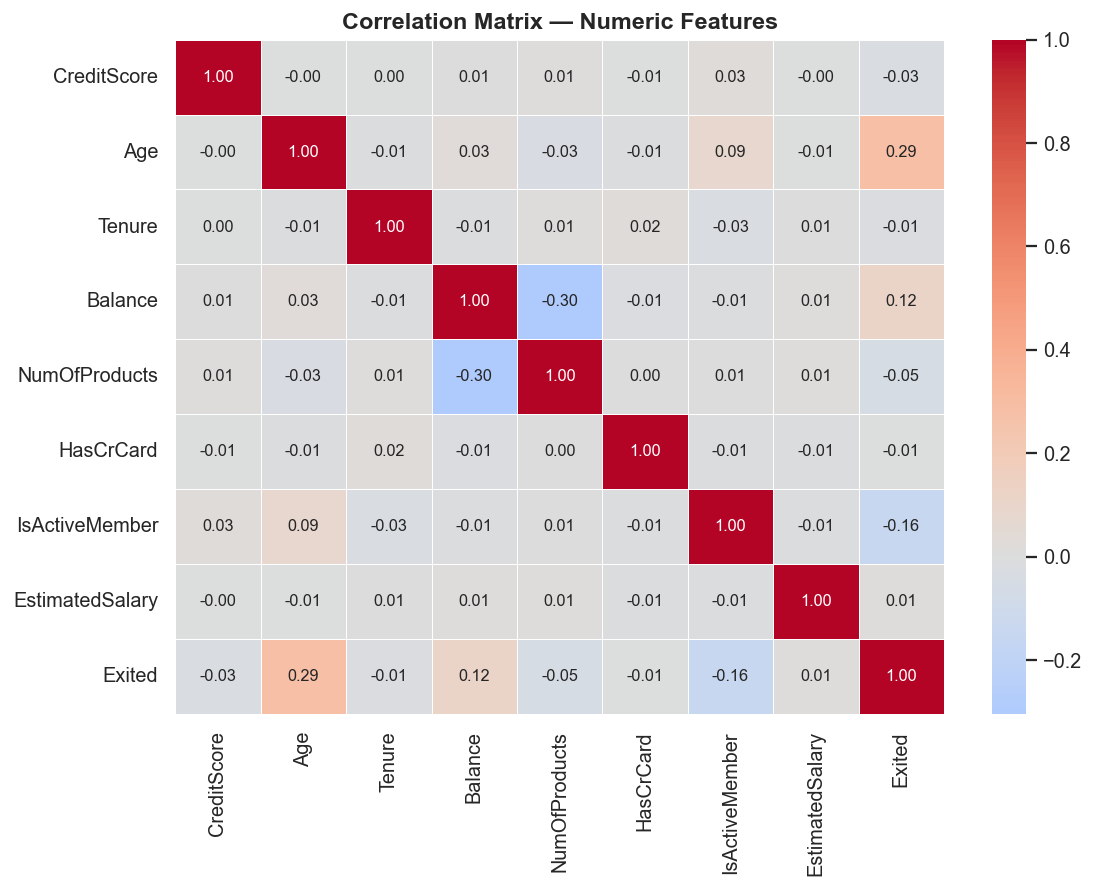

In [11]:
numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Exited'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('../notebooks/chart8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Feature engineering 

In [12]:
# Feature 5 — Churn revenue impact estimate
# Assumes average estimated salary as proxy for annual revenue per customer
avg_salary = df['EstimatedSalary'].mean()

df['revenue_at_risk'] = df.apply(
    lambda row: round(row['EstimatedSalary'] * 0.15, 2)
    if row['Exited'] == 1 else 0, axis=1
)

# Feature 6 — Engagement score
# Combines tenure, active membership and products into one metric
def engagement_score(row):
    score = 0
    if row['IsActiveMember'] == 1: score += 3
    if row['Tenure'] >= 7:         score += 2
    elif row['Tenure'] >= 4:       score += 1
    if row['NumOfProducts'] == 2:  score += 2
    elif row['NumOfProducts'] == 1:score += 1
    if row['HasCrCard'] == 1:      score += 1
    return score

df['engagement_score'] = df.apply(engagement_score, axis=1)

# Verify
print("Revenue at risk from churned customers:")
print(f"  Total: ${df['revenue_at_risk'].sum():,.2f}")
print(f"  Avg per churned customer: ${df[df['Exited']==1]['revenue_at_risk'].mean():,.2f}")
print()
print("Engagement score distribution:")
print(df['engagement_score'].value_counts().sort_index())

Revenue at risk from churned customers:
  Total: $31,002,837.66
  Avg per churned customer: $15,219.85

Engagement score distribution:
engagement_score
0      22
1     318
2    1088
3    1525
4    1698
5    1746
6    1619
7    1383
8     601
Name: count, dtype: int64


## Final Export

In [16]:
export_cols = [
    'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'age_band',
    'Tenure', 'Balance', 'balance_segment', 'credit_band', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
    'value_tier', 'revenue_at_risk', 'engagement_score'
]

df[export_cols].to_csv('../data/churn_clean_export.csv', index=False)

print(f"Exported {len(df):,} rows × {len(export_cols)} columns")
print("Saved to: data/churn_clean_export.csv")

Exported 10,000 rows × 18 columns
Saved to: data/churn_clean_export.csv


## Churn Rate by Tenure Year

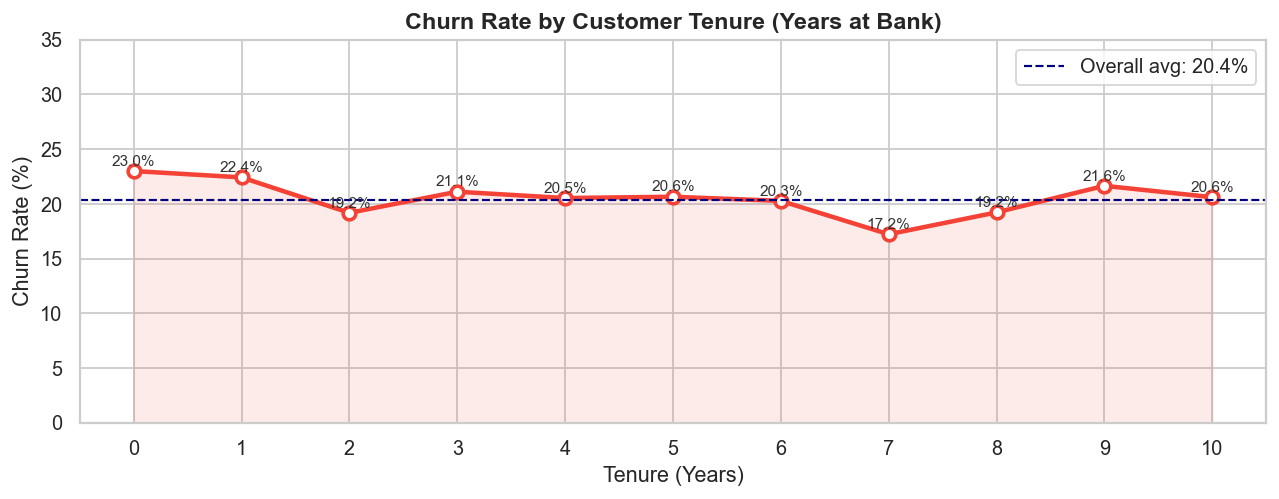


Highest churn tenure: Year 0 (23.0%)
Lowest churn tenure:  Year 7 (17.2%)


In [13]:
# Chart 9 — Churn rate by tenure year
tenure_churn = (df.groupby('Tenure')['Exited']
                  .mean()
                  .mul(100)
                  .round(2))

fig, ax = plt.subplots(figsize=(10, 4))

# Line
ax.plot(tenure_churn.index, tenure_churn.values,
        color='#F44336', linewidth=2.5, marker='o',
        markersize=7, markerfacecolor='white',
        markeredgecolor='#F44336', markeredgewidth=2)

# Shade area under line
ax.fill_between(tenure_churn.index, tenure_churn.values,
                alpha=0.1, color='#F44336')

# Label each point
for x, y in zip(tenure_churn.index, tenure_churn.values):
    ax.text(x, y + 0.5, f'{y:.1f}%',
            ha='center', fontsize=8.5, color='#333333')

# Average reference line
avg = df['Exited'].mean() * 100
ax.axhline(avg, color='navy', linestyle='--',
           linewidth=1.2, label=f'Overall avg: {avg:.1f}%')

ax.set_title('Churn Rate by Customer Tenure (Years at Bank)')
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(0, 11))
ax.set_ylim(0, 35)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart9_churn_by_tenure.png', bbox_inches='tight')
plt.show()

print(f"\nHighest churn tenure: Year {tenure_churn.idxmax()} ({tenure_churn.max():.1f}%)")
print(f"Lowest churn tenure:  Year {tenure_churn.idxmin()} ({tenure_churn.min():.1f}%)")

## END OF PHASE 3